<a href="https://colab.research.google.com/github/JiyaKakadiya/Jiya-Kakadiya/blob/main/Data_Cleaning_%26_Reporting_Automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     STARTING AUTOMATED DATA CLEANING PIPELINE           

[LOG] Raw Dataset Loaded Successfully: 9800 rows found.
[LOG] Scanning for Duplicates... Removed 0 duplicate rows.
[LOG] Scanning for Missing Values...
      -> Fixed 11 missing Postal Codes.
[LOG] Data formats standardisation complete.
[SUCCESS] Cleaned dataset ready. Final row count: 9800 rows.

     GENERATING AUTOMATED REPORT & VISUAL SUMMARY        

--- AUTOMATED PERFORMANCE REPORT ---
Total Operational Revenue : $2,261,536.78
Total Unique Orders Placed: 4,922
Average Order Value (AOV) : $459.48

[LOG] Compiling visual metrics summary graph...


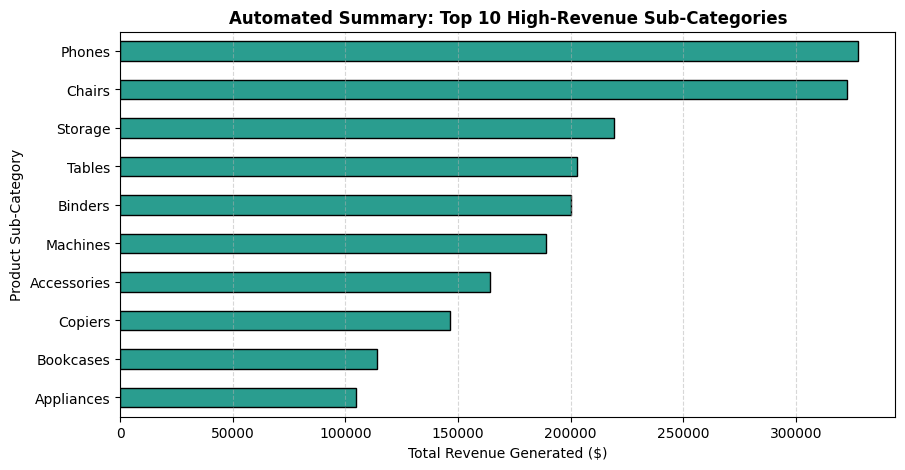

[SUCCESS] Visual report exported to sidebar as 'automated_visual_summary.png'
[SUCCESS] Master clean dataset exported as 'Automated_Clean_Data.csv'

             PIPELINE EXECUTION COMPLETE                 


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("=========================================================")
print("     STARTING AUTOMATED DATA CLEANING PIPELINE           ")
print("=========================================================\n")

# 1. Automated Data Loading
file_path = 'train.csv'
if not os.path.exists(file_path):
    print(f"[ERROR] Could not find {file_path}. Please upload it to the sidebar.")
else:
    df = pd.read_csv(file_path)
    print(f"[LOG] Raw Dataset Loaded Successfully: {df.shape[0]} rows found.")

    # 2. Automated Duplicate Detection & Removal
    initial_rows = len(df)
    df = df.drop_duplicates()
    duplicate_count = initial_rows - len(df)
    print(f"[LOG] Scanning for Duplicates... Removed {duplicate_count} duplicate rows.")

    # 3. Automated Handling of Missing Values
    print("[LOG] Scanning for Missing Values...")
    # Fill missing Postal Codes with a default indicator
    if 'Postal Code' in df.columns:
        missing_postal = df['Postal Code'].isnull().sum()
        df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)
        print(f"      -> Fixed {missing_postal} missing Postal Codes.")

    # 4. Automated Data Consistency Standardisation
    # Convert dates automatically and drop rows with corrupted date entries
    df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
    df = df.dropna(subset=['Order Date'])

    # Strip any accidental white spaces from categorical values
    df['Category'] = df['Category'].str.strip()
    df['Sub-Category'] = df['Sub-Category'].str.strip()

    print("[LOG] Data formats standardisation complete.")
    print(f"[SUCCESS] Cleaned dataset ready. Final row count: {len(df)} rows.")

    print("\n=========================================================")
    print("     GENERATING AUTOMATED REPORT & VISUAL SUMMARY        ")
    print("=========================================================\n")

    # 1. Generate Executive Financial Metrics Summary
    total_sales = df['Sales'].sum()
    total_orders = df['Order ID'].nunique()
    avg_order_value = total_sales / total_orders

    print("--- AUTOMATED PERFORMANCE REPORT ---")
    print(f"Total Operational Revenue : ${total_sales:,.2f}")
    print(f"Total Unique Orders Placed: {total_orders:,}")
    print(f"Average Order Value (AOV) : ${avg_order_value:,.2f}\n")

    # 2. Automated Visual Summary Generation (Top Sub-Categories)
    print("[LOG] Compiling visual metrics summary graph...")
    sub_cat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)

    plt.figure(figsize=(10, 5))
    sub_cat_sales.plot(kind='barh', color='#2a9d8f', edgecolor='black')

    plt.title('Automated Summary: Top 10 High-Revenue Sub-Categories', fontsize=12, fontweight='bold')
    plt.xlabel('Total Revenue Generated ($)', fontsize=10)
    plt.ylabel('Product Sub-Category', fontsize=10)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Save the automated visual report out to your file space
    report_chart_name = 'automated_visual_summary.png'
    plt.savefig(report_chart_name, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"[SUCCESS] Visual report exported to sidebar as '{report_chart_name}'")

    # 3. Export the Cleaned Dataset automatically
    cleaned_file_name = 'Automated_Clean_Data.csv'
    df.to_csv(cleaned_file_name, index=False)
    print(f"[SUCCESS] Master clean dataset exported as '{cleaned_file_name}'")
    print("\n=========================================================")
    print("             PIPELINE EXECUTION COMPLETE                 ")
    print("=========================================================")